In [20]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
sns.set_style('whitegrid')

# Step 2: Fetch historical stock data
# Tesla (TSLA)
ticker = "TSLA"
data = yf.download(ticker, start="2010-01-01", end="2026-01-01")  # adjust dates if needed
data.reset_index(inplace=True)

/tmp/ipython-input-930560535.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2010-01-01", end="2026-01-01")  # adjust dates if needed
[*********************100%***********************]  1 of 1 completed


In [34]:
df = data.reset_index()

df.head()


Price,level_0,index,Date,Close,High,Low,Open,Volume
Ticker,,,,TSLA,TSLA,TSLA,TSLA,TSLA
0,0,0,2010-06-29,1.592667,1.666667,1.169333,1.266667,281494500
1,1,1,2010-06-30,1.588667,2.028000,1.553333,1.719333,257806500
2,2,2,2010-07-01,1.464000,1.728000,1.351333,1.666667,123282000
3,3,3,2010-07-02,1.280000,1.540000,1.247333,1.533333,77097000
4,4,4,2010-07-06,1.074000,1.333333,1.055333,1.333333,103003500


In [36]:
df.shape

(3902, 8)

In [37]:
df.tail()

Price,level_0,index,Date,Close,High,Low,Open,Volume
Ticker,,,,TSLA,TSLA,TSLA,TSLA,TSLA
3897,3897,3897,2025-12-24,485.399994,490.899994,476.799988,488.480011,41285400
3898,3898,3898,2025-12-26,475.190002,489.089996,473.820007,485.230011,58780700
3899,3899,3899,2025-12-29,459.640015,469.399994,459.000000,469.000000,66263000
3900,3900,3900,2025-12-30,454.429993,463.119995,453.829987,461.089996,59238500
3901,3901,3901,2025-12-31,449.720001,456.549988,449.299988,456.100006,49078000


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3902 entries, 0 to 3901
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   (level_0, )     3902 non-null   int64         
 1   (index, )       3902 non-null   int64         
 2   (Date, )        3902 non-null   datetime64[ns]
 3   (Close, TSLA)   3902 non-null   float64       
 4   (High, TSLA)    3902 non-null   float64       
 5   (Low, TSLA)     3902 non-null   float64       
 6   (Open, TSLA)    3902 non-null   float64       
 7   (Volume, TSLA)  3902 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(3)
memory usage: 244.0 KB


In [39]:
df.describe()

Price,level_0,index,Date,Close,High,Low,Open,Volume
Ticker,,,,TSLA,TSLA,TSLA,TSLA,TSLA
count,3902.000000,3902.000000,3902,3902.000000,3902.000000,3902.000000,3902.000000,3.902000e+03
mean,1950.500000,1950.500000,2018-03-29 00:55:21.373654528,99.172240,101.366903,96.874590,99.192439,9.674288e+07
min,0.000000,0.000000,2010-06-29 00:00:00,1.053333,1.108667,0.998667,1.076000,1.777500e+06
25%,975.250000,975.250000,2014-05-14 06:00:00,12.795333,12.966000,12.539167,12.734166,5.142075e+07
50%,1950.500000,1950.500000,2018-03-28 12:00:00,19.922999,20.302000,19.540667,19.901667,8.331105e+07
75%,2925.750000,2925.750000,2022-02-09 18:00:00,207.660000,212.685829,202.569996,208.107502,1.211088e+08
max,3901.000000,3901.000000,2025-12-31 00:00:00,489.880005,498.829987,485.329987,489.880005,9.140820e+08
std,1126.554704,1126.554704,NaN,125.311597,128.114475,122.412518,125.388731,7.570527e+07


In [40]:
df.isna().sum()

,,0
Price,Ticker,
level_0,,0
index,,0
Date,,0
Close,TSLA,0
High,TSLA,0
Low,TSLA,0
Open,TSLA,0
Volume,TSLA,0


In [41]:
df.duplicated().sum()

np.int64(0)

In [47]:
# Model training + prediction
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)


In [48]:
dfForVisualization = pd.DataFrame()

dfForVisualization['Date'] = df['Date'].iloc[-len(y_test):].values
dfForVisualization['Actual_Close'] = y_test.values
dfForVisualization['Predicted_Close'] = y_pred


In [50]:
dfForVisualization


,Date,Actual_Close,Predicted_Close
0,2024-10-17,220.889999,220.888144
1,2024-10-18,220.699997,219.345828
2,2024-10-21,218.850006,221.100766
3,2024-10-22,217.970001,218.016567
4,2024-10-23,213.649994,216.771061
...,...,...,...
297,2025-12-24,485.399994,483.507896
298,2025-12-26,475.190002,478.563463
299,2025-12-29,459.640015,476.695636
300,2025-12-30,454.429993,458.827104


In [51]:
dfForVisualization['Date'] = pd.to_datetime(dfForVisualization['Date'])

In [53]:
dfForVisualization['Year'] = dfForVisualization['Date'].dt.year

In [58]:
dfForVisualization['Volume'] = df['Volume'].iloc[-len(y_test):].values


In [60]:
dfForVisualization['Year'] = pd.to_datetime(dfForVisualization['Date']).dt.year


<Figure size 1500x600 with 0 Axes>

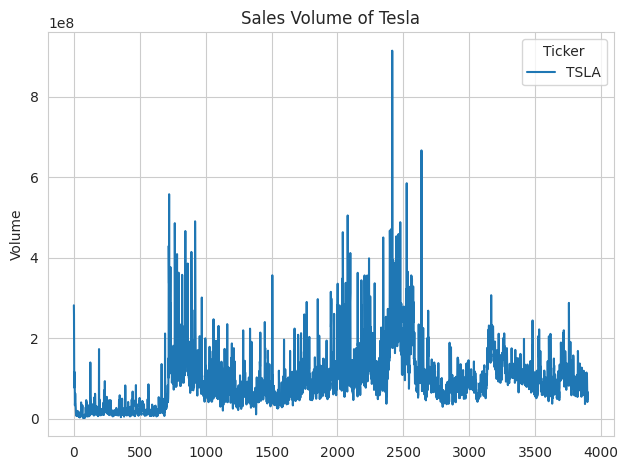

In [64]:
plt.figure(figsize=(15, 6))
df['Volume'].plot()
plt.ylabel('Volume')
plt.xlabel(None)
plt.title("Sales Volume of Tesla")
plt.tight_layout()
plt.show()

In [72]:
data['Next_Close'] = data['Close'].shift(-1)  # Shift Close price to predict next day's Close
data.dropna(inplace=True)

In [73]:
X = data[['Open', 'High', 'Low', 'Volume']]
y = data['Next_Close']

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

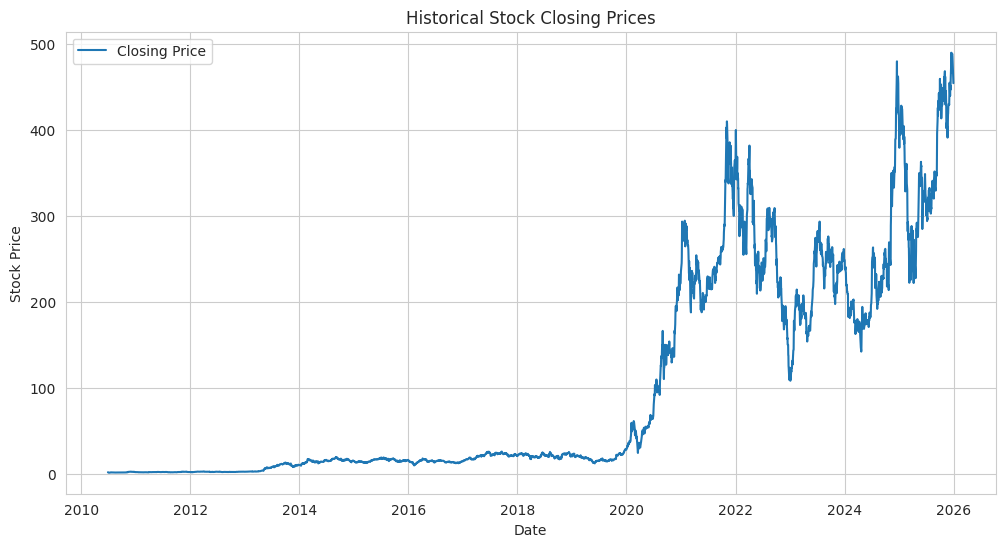

In [75]:
plt.figure(figsize=(12,6))
plt.plot(data['Date'], data['Close'], label="Closing Price")
plt.title("Historical Stock Closing Prices")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.show()


In [76]:
df

Price,level_0,index,Date,Close,High,Low,Open,Volume
Ticker,,,,TSLA,TSLA,TSLA,TSLA,TSLA
0,0,0,2010-06-29,1.592667,1.666667,1.169333,1.266667,281494500
1,1,1,2010-06-30,1.588667,2.028000,1.553333,1.719333,257806500
2,2,2,2010-07-01,1.464000,1.728000,1.351333,1.666667,123282000
3,3,3,2010-07-02,1.280000,1.540000,1.247333,1.533333,77097000
4,4,4,2010-07-06,1.074000,1.333333,1.055333,1.333333,103003500
...,...,...,...,...,...,...,...,...
3897,3897,3897,2025-12-24,485.399994,490.899994,476.799988,488.480011,41285400
3898,3898,3898,2025-12-26,475.190002,489.089996,473.820007,485.230011,58780700
3899,3899,3899,2025-12-29,459.640015,469.399994,459.000000,469.000000,66263000


In [77]:
data.dropna(inplace=True)

data.head()

Price,index,Date,Close,High,Low,Open,Volume,Next_Close
Ticker,,,TSLA,TSLA,TSLA,TSLA,TSLA,
0,0,2010-06-29,1.592667,1.666667,1.169333,1.266667,281494500,1.588667
1,1,2010-06-30,1.588667,2.028000,1.553333,1.719333,257806500,1.464000
2,2,2010-07-01,1.464000,1.728000,1.351333,1.666667,123282000,1.280000
3,3,2010-07-02,1.280000,1.540000,1.247333,1.533333,77097000,1.074000
4,4,2010-07-06,1.074000,1.333333,1.055333,1.333333,103003500,1.053333


In [78]:
open_close = df[['Open','Close']]

In [12]:
split = int(len(data) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


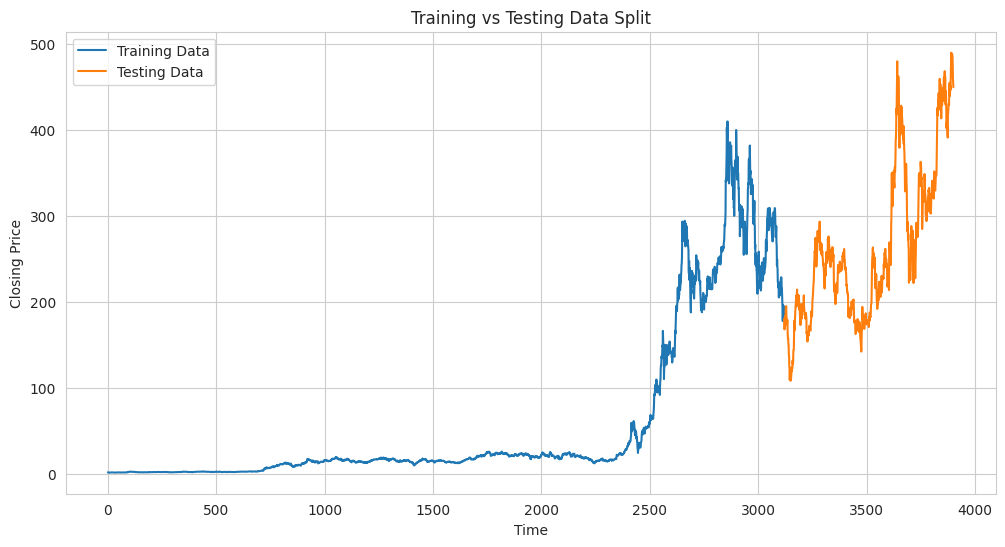

In [87]:
plt.figure(figsize=(12,6))
plt.plot(y_train.values, label="Training Data")
plt.plot(
    range(len(y_train), len(y_train) + len(y_test)),
    y_test.values,
    label="Testing Data"
)
plt.title("Training vs Testing Data Split")
plt.xlabel("Time")
plt.ylabel("Closing Price")
plt.legend()
plt.show()


In [88]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [89]:
y_pred = model.predict(X_test)
y_pred[:20]  # show first 20 predictions


array([183.45121035, 178.40218845, 169.98152076, 168.71041588,
       180.89364511, 181.78064524, 186.18360003, 181.21915395,
       190.92922829, 194.47572866, 195.06556217, 183.81423614,
       178.56007929, 176.42229626, 172.28221197, 180.56893202,
       170.3048348 , 160.47349966, 158.22090681, 159.52409856])

In [90]:
dataset = df['Close']
dataset = pd.DataFrame(dataset)
dataset

Ticker,TSLA
0,1.592667
1,1.588667
2,1.464000
3,1.280000
4,1.074000
...,...
3897,485.399994
3898,475.190002
3899,459.640015
3900,454.429993


In [92]:
dataset.shape

(3902, 1)

In [91]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

MAE: 7.69
RMSE: 10.55
R² Score: 0.9861


In [105]:
time

CPU times: user 3 µs, sys: 0 ns, total: 3 µs
Wall time: 6.2 µs
